# Práctica 4: Multiperceptrón

## Parte 1 - Multiperceptrón con SciKit-Learn

### Ejercicio 1

Se entrenó una red neuronal multiperceptrón para resolver un problema de clasificación y al medir su desempeño sobre el conjunto de datos de entrenamiento se obtuvo la siguiente matriz de confusión: 

| 17 | 0 | 1 | 0 | 1 |
|----|---|---|---|---|
| 0 | 12 | 0 | 0 | 0 |
| 0 | 0 | 12 | 0 | 0 |
| 2 | 0 | 0 | 38 | 0 |
| 0 | 8 | 0 | 0 | 61 |

1. En base a esta información, indique:
   - Cuántos ejemplos se utilizaron en el entrenamiento.
  
Se usaron $152$ ejemplos en el entrenamiento: $152 = 17 + 1 + 1 + 12 + 12 + 2 + 38 + 8 + 61$.

   - Cuántas clases puede reconocer este multiperceptrón.

Puede reconocer 5 clases (número de columnas de la matriz).

   - Cuál es la precisión (**accuracy**) de la red sobre el conjunto de ejemplos completo.

El **accuracy** se calcula como los ejemplos predecidos correctamente / los ejemplos totales: $\frac{140}{152} = 92.10\%$

   - Cuáles son los valores de precisión de la red al responder por cada uno de los valores de clase (**precision**).

La **precisión** a nivel de clase se calcula como los ejemplos predecidos correctamente / los ejemplos predecidos para la clase:
- Clase 1: $\frac{17}{19} = 89.47\%$
- Clase 2: $\frac{12}{20} = 60\%$
- Clase 3: $\frac{12}{13} = 92.31\%$
- Clase 4: $\frac{38}{38} = 100\%$
- Clase 5: $\frac{61}{62} = 98.39\%$

   - Cuáles son los valores de sensibilidad de la red al responder por cada uno de los valores de clase (**recall**).

Lo mismo que antes pero a nivel de fila:
- Clase 1: $\frac{17}{19} = 89.47\%$
- Clase 2: $\frac{12}{12} = 100\%$
- Clase 3: $\frac{12}{12} = 100\%$
- Clase 4: $\frac{38}{40} = 95\%$
- Clase 5: $\frac{61}{69} = 88.40\%$

2. Identifique la clase con el mejor valor de F1-score.

El F1-score se calcula como $2 \cdot \frac{precision\ \cdot\ recall}{precision\ +\ recall}$
- Clase 1: $2 \cdot \frac{0.8947 \cdot 0.8947}{0.8947 + 0.8947} = 0.8947$
- Clase 2: $2 \cdot \frac{0.6 \cdot 1}{0.6 + 1} = 0.75$
- Clase 3: $2 \cdot \frac{0.9231 \cdot 1}{0.9231 + 1} = 0.96$
- Clase 4: $2 \cdot \frac{1 \cdot 0.95}{1 + 0.95} = 0.9743$
- Clase 5: $2 \cdot \frac{0.9839 \cdot 0.8840}{0.9839 + 0.8840} = 0.9312$

La clase con mayor F1-score es la **CLase 4**.

### Ejercicio 2

Se desea utilizar una red multiperceptrón para reconocer muestras de tres variedades diferentes de trigo: Kama, Rosa y Canadiense. Para entrenarla se utilizará una parte de los ejemplos del archivo **SEMILLAS.CSV**.

Fuente de datos: **Seeds Data Set** - [https://archive.ics.uci.edu/ml/datasets/seeds](https://archive.ics.uci.edu/ml/datasets/seeds)

1. Con respecto a la arquitectura, indique:
   - La cantidad de neuronas de la capa de entrada.
  
La cantidad de neuronas de la capa de entrada serían 8 (todas las columnas menos la que queremos predecir + 1 por el bias)

   - La cantidad de neuronas de la capa de salida.

La cantidad de neuronas de la capa de salida serían 3, una por cada tipo de trigo.

   - La cantidad de pesos (arcos) que tiene la red si se utiliza una única capa oculta formada por 4 neuronas.

La cantidad de arcos de la red se calcularía como: $(8 \cdot 4) + (4 \cdot 3) = 44$

2. La arquitectura del multiperceptrón utilizado para predecir los 3 tipos de semillas está formada por 3 capas: la capa de entrada, una única capa oculta de 4 neuronas y la capa de salida. Las funciones de activación para las capas oculta y de salida son “tanh” y “sigmoid” respectivamente. Indique cuáles de los siguientes factores inciden en la dirección de cambio (signo de la modificación) de los pesos de la red:
   - El error cometido en la predicción.
   - El valor de la derivada de la función de activación.
   - Los valores anteriores de los pesos de la red.

Los factores que inciden en la dirección de cambio de los pesos de la red serían El error cometido en la predicción y Los valores anteriores de los pesos de la red.

3. Luego de ingresar una muestra de semilla a la red se obtiene como salida (0.78, 0, 0). Utilizando la arquitectura descripta en b), indique cuántos pesos de la red serán modificados sabiendo que la respuesta esperada es (1, 0, 0).

La cantidad de pesos que se tienen que modificar serían 4 que son los que le llegan a la neurona de la capa de salida que predice Tipo1, y luego todos los que conectan la capa de entrada con la capa oculta, es decir, $(8 \cdot 4) + 4 = 36$.

In [1]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

df_semillas = pd.read_csv("../Datos/semillas.csv")

df_semillas.head(5)

,Area,Perimetro,Compacidad,LongNucleo,AnchoNucleo,Asimetria,LongSurco,Clase
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,Tipo1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,Tipo1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,Tipo1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,Tipo1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,Tipo1


### Ejercicio 3

El archivo **Vinos.csv** tiene información referida a 13 características químicas y/o visuales de varias muestras de vinos pertenecientes a 3 clases distintas.

Utilice el 80% de los ejemplos del archivo Vinos.csv para entrenar un multiperceptrón que sea capaz que distinguir entre las 3 clases de vinos. Observe la tasa de acierto obtenida sobre el 20% restante.

Fuente de datos: **Wine Data Set** - [https://archive.ics.uci.edu/ml/datasets/wine](https://archive.ics.uci.edu/ml/datasets/wine)

In [16]:
def visualizar_en_2d(X_scaled, y):
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y)
    plt.title("Distribución de las clases en 2D usando t-SNE")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()

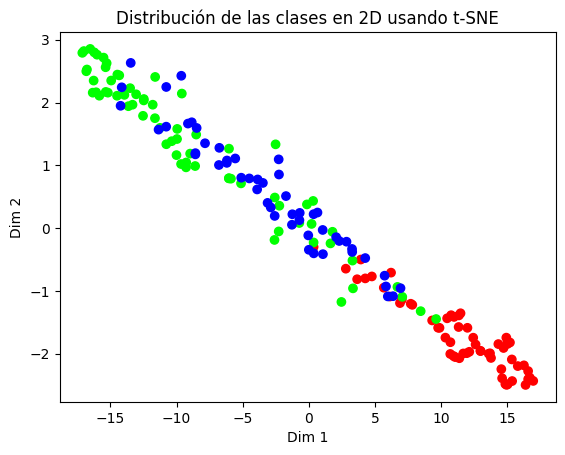

y_pred: [[0 0 1]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [1 0 0]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [0 1 0]
 [0 1 0]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [1 0 0]
 [0 0 1]
 [1 0 0]
 [0 1 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]]
acc_score: 0.9166666666666666


In [70]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

df_vinos = pd.read_csv("../Datos/Vinos.csv", delimiter=";")

X = np.array(df_vinos.iloc[:,1:])
y = np.array(df_vinos.iloc[:,0])

label_binarizer = LabelBinarizer()
y = label_binarizer.fit_transform(y)

visualizar_en_2d(X, y)

standard_scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

alpha = 0.1
error = 1.0e-4
iteraciones = 5000

model = MLPClassifier(
    max_iter=iteraciones,
    hidden_layer_sizes=(2),
    alpha=alpha,
    solver="adam",
    activation="tanh",
    tol=error,
    verbose=False
).fit(
    X_train,
    y_train
)

y_pred = model.predict(X_test)
acc_score = accuracy_score(y_test, y_pred)

print(f"y_pred: {y_pred}")
print(f"acc_score: {acc_score}")

### Ejercicio 4

El archivo **Balance.csv** tiene información sobre un experimento psicológico realizado para evaluar el aprendizaje en los niños. Cada fila de la tabla tiene las características de una balanza, referidas a la longitud de los brazos izquierdo y derecho de la balanza y al peso que hay en cada brazo, y un atributo que indica si la balanza se inclina al lado izquierdo (**L**), derecho (**R**), o está balanceada (**B**).

Utilice una parte de los ejemplos para entrenar un multiperceptrón que sea capaz que predecir si la balanza está inclinada a derecha, a izquierda o si está balanceada. Analice la precisión de la red sobre los ejemplos de entrenamiento y sobre los de testeo.

Fuente: **Balance Scale Data Set** - https://archive.ics.uci.edu/ml/datasets/Balance+Scale

,Balance,LeftWeight,LeftDist,RightWeight,RightDist
0,B,1,1,1,1
1,R,1,1,1,2
2,R,1,1,1,3
3,R,1,1,1,4
4,R,1,1,1,5


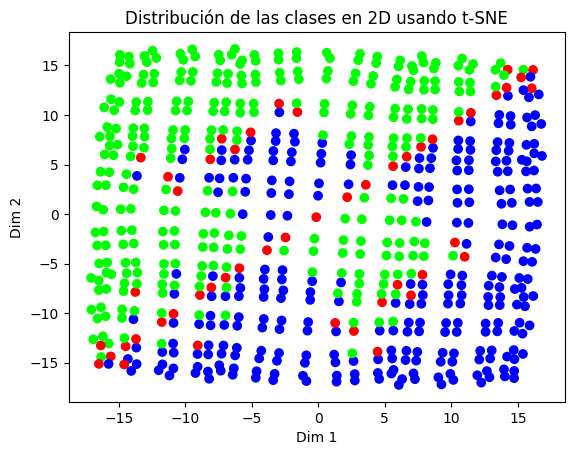

prec_score_train: [0.975 1.    1.   ]
prec_score_test: [0.81818182 1.         1.        ]


In [69]:
df_balance = pd.read_csv('../Datos/Balance.csv')

display(df_balance.head())

X = np.array(df_balance.iloc[::,1::])
y = np.array(df_balance.iloc[::,0])

y = label_binarizer.fit_transform(y)

visualizar_en_2d(X,y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

alpha = 0.1
error = 1.0e-4
iteraciones = 5000

model = MLPClassifier(
    max_iter=iteraciones,
    hidden_layer_sizes=(16,8),
    alpha=alpha,
    solver="adam",
    activation="tanh",
    tol=error,
    verbose=False
).fit(
    X_train,
    y_train
)

y_pred = model.predict(X_train)
prec_score = precision_score(y_train, y_pred, average=None)

#print(f"y_pred_train: {y_pred}")
print(f"prec_score_train: {prec_score}")

y_pred = model.predict(X_test)
prec_score = precision_score(y_test, y_pred, average=None)

#print(f"y_pred_test: {y_pred}")
print(f"prec_score_test: {prec_score}")

### Ejercicio 5

El archivo **ZOO.csv** contiene información de 101 animales caracterizados por los siguientes atributos
1. Nombre del animal
2. Tiene Pelo
3. Plumas
4. Huevos
5. Leche
6. Vuela
7. Acuático
8. Depredador
9. Dentado
10. Vertebrado
11. Branquias
12. Venenoso
13. Aletas
14. Patas
15. Cola
16. Domestico
17. Tamaño gato
18. Clase

Salvo los atributos 1 y 18 que contienen texto y el 14 que contiene el número de patas del animal, el resto toma el valor 1 si el animal posee la característica y 0 si no. Hay 7 valores de clase posible (atributo 18): mamífero, ave, pez, invertebrado, insecto, reptil y anfibio.

Entrene un multiperceptrón que sea capaz de clasificar un animal en una de las 7 clases. Utilice el 70% de los ejemplos para entrenar y el 30% para realizar el testeo. Realice al menos 10 ejecuciones independientes de la configuración seleccionada para respaldar sus afirmaciones referidas a la performance del modelo.

Fuente de Datos: **Zoo Data Set** - https://archive.ics.uci.edu/ml/datasets/zoo

In [50]:
df_zoo = pd.read_csv('../Datos/zoo.csv', encoding='latin1')
display(df_zoo.head())

X = np.array(df_zoo.iloc[::,1:17])
y = np.array(df_zoo.iloc[::,17])

y = label_binarizer.fit_transform(y)

#visualizar_en_2d(X,y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

alpha = 0.1
error = 1.0e-4
iteraciones = 5000

model = MLPClassifier(
    max_iter=iteraciones,
    hidden_layer_sizes=(16,8),
    alpha=alpha,
    solver="adam",
    activation="tanh",
    tol=error,
    verbose=False
).fit(
    X_train,
    y_train
)


y_pred = model.predict(X_train)
acc_score = accuracy_score(y_train, y_pred)

print(f"acc_score_train: {acc_score}")

y_pred = model.predict(X_test)
acc_score = accuracy_score(y_test, y_pred)

print(f"acc_score_pred: {acc_score}")

,animal,Tiene_Pelo,Tiene_Plumas,Nace_de_huevo,Toma_Leche,Vuela,Acuatico,Depredador,Dentado,Vertebrado,Respira,Venenoso,Tiene_Aletas,Cant_Patas,Tiene_Cola,Domestico,Tamano_Gato,Clase
0,oso_hormiguero,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,Mamifero
1,antilope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,Mamifero
2,robalo,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,Pez
3,oso,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,Mamifero
4,jabali,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,Mamifero


acc_score_train: 1.0
acc_score_pred: 0.9032258064516129


### Ejercicio 6

Los archivos **Segment_Train.csv** y **Segment_Test.csv** contienen información referida a regiones de 3x3 pixeles pertenecientes a 7 imágenes distintas. Cada una corresponde a uno de los siguientes tipos de superficie: ladrillo, cielo, follaje, cemento, ventana, camino y pasto.

Cada región de 3x3 ha sido caracterizada por 19 atributos numéricos:

1. **region-centroid-col**: la columna del pixel central de la región.
2. **region-centroid-row**: la fila del pixel central de la región.
3. **region-pixel-count**: el número de pixeles de la región = 9.
4. **short-line-density-5**: el resultado de un algoritmo de extracción de líneas que cuenta la cantidad de líneas de bajo contraste que atraviesan la región.
5. **short-line-density-2**: ídem anterior para líneas de alto contraste.
6. **vedge-mean**: medida del contraste entre pixeles adyacentes. Este atributo contiene el valor promedio y el siguiente la desviación. Estas medidas sirven para detectar la presencia de un eje vertical.
7. **vegde-sd**: (ver 6)
8. **hedge-mean**: ídem 6 para eje horizontal. Contiene el valor medio y el siguiente la desviación.
9. **hedge-sd**: (ver 8).
10. **intensity-mean**: El promedio calculado sobre la región de la forma (R + G + B)/3
11. **rawred-mean**: el promedio sobre la región de los valores R.
12. **rawblue-mean**: el promedio sobre la región de los valores B.
13. **rawgreen-mean**: el promedio sobre la región de los valores G.
14. **exred-mean**: Medida de exceso de color rojo: (2R - (G + B))
15. **exblue-mean**: Medida de exceso de color azul: (2B - (G + R))
16. **exgreen-mean**: Medida de exceso de color verde: (2G - (R + B))
17. **value-mean**: Transformación no lineal 3D de RGB.
18. **saturatoin-mean**: (ver 17)
19. **hue-mean**: ver 17)
    
El atributo 20 corresponde al número de imagen de la cual fue extraída la región de 3x3. Sus valores son: 1 (ladrillo), 2 (cemento), 3(follaje), 4 (pasto), 5 (camino), 6 (cielo), 7 (ventana).
Entrene una red neuronal multiperceptrón para que dada una región de 3x3, representada a través de los 19 atributos indicados anteriormente, sea capaz de identificar a cuál de las 7 imágenes corresponde.
Utilice los ejemplos del archivo **Segment_Train.csv** para entrenar y los del archivo **Segment_Test.csv** para realizar el testeo.
Realice al menos 10 ejecuciones independientes de la configuración seleccionada para respaldar sus afirmaciones referidas a la performance del modelo.

Fuente: **Image Segmentation Data Set**: https://archive.ics.uci.edu/ml/datasets/Image+Segmentation

In [76]:
df_segment_train = pd.read_csv('../Datos/segment_train.csv')
df_segment_test = pd.read_csv('../Datos/segment_test.csv')

X_train = np.array(df_segment_train.iloc[::,1::])
y_train = np.array(df_segment_train.iloc[::,0])

X_test = np.array(df_segment_test.iloc[::,1::])
y_test = np.array(df_segment_test.iloc[::,0])

y_train = label_binarizer.fit_transform(y_train)
y_test = label_binarizer.fit_transform(y_test)

X_train = standard_scaler.fit_transform(X_train)
X_test = standard_scaler.transform(X_test)

#visualizar_en_2d(X_train,y_train)
alpha = 0.1
error = 1.0e-4
iteraciones = 5000

model = MLPClassifier(
    max_iter=iteraciones,
    hidden_layer_sizes=(8,8),
    alpha=alpha,
    solver="adam",
    activation="tanh",
    tol=error,
    verbose=False
).fit(
    X_train,
    y_train
)


y_pred = model.predict(X_train)
acc_score = accuracy_score(y_train, y_pred)

print(f"acc_score_train: {acc_score}")

y_pred = model.predict(X_test)
acc_score = accuracy_score(y_test, y_pred)

print(f"acc_score_pred: {acc_score}")

acc_score_train: 0.9285714285714286
acc_score_pred: 0.8609523809523809
